# EVA02. Diagnóstico y Análisis Predictivo sobre un Conjunto de Datos de Mediciones Eléctricas
**Asignatura:** Minería de Datos  
**Estudiante:** Manuel de Jesus Hernandez Zacarías  
**Matricula:** 233322  
**Fecha de entrega:** Mañana, 4 de Julio de 2026  
**Objetivo:** Desarrollar un proceso completo de Ciencia de Datos (CRISP-DM) para diagnosticar la salud de 24 inversores en una planta solar fotovoltaica, modelar la conversión de potencia DC a AC, y pronosticar la generación agregada de energía de la planta solar.

---

## 1. Comprensión del Problema

### Contexto y Planteamiento
Las plantas solares fotovoltaicas (PV) a gran escala constan de múltiples arreglos de paneles solares conectados a **inversores**, los cuales convierten la corriente continua (DC) generada por los paneles en corriente alterna (AC) inyectable a la red eléctrica. Monitorear la eficiencia y el comportamiento de estos dispositivos es crucial para minimizar las pérdidas de energía.

El conjunto de datos `2107_electrical_data.csv` contiene **632,952 registros temporales** a una frecuencia de **5 minutos** (de noviembre de 2017 a noviembre de 2023). Contempla 120 variables de sensores de 24 inversores distintos.

### Preguntas de Negocio y Objetivos Técnicos:
1. **Diagnóstico no supervisado (Salud del Inversor):** ¿Podemos clasificar automáticamente a los 24 inversores según su eficiencia operativa y detectar patrones anómalos (como degradación de paneles, soiling/suciedad o sensores dañados)?
2. **Modelo Virtual de Conversión (Supervisado):** ¿Cómo de bien podemos modelar la potencia de salida AC a partir de variables DC en un inversor de control? ¿Existe un comportamiento lineal o se requiere modelado no lineal?
3. **Pronóstico de Producción (Forecasting):** ¿Es posible predecir con precisión la generación neta de la planta a 24 horas vista usando variables históricas auto-regresivas, facilitando la programación de red?

---

In [1]:
# Imports y configuración del entorno de trabajo
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Añadir el directorio raíz al path para poder importar src
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_data
from src.preprocessing import clean_and_impute, feature_engineering, filter_daylight, get_inverter_cols
from src.clustering import extract_inverter_features, run_kmeans_analysis, perform_final_clustering
from src.regression import prepare_regression_data, train_and_compare_regressors
from src.forecasting import prepare_forecasting_data, run_forecasting_analysis

# Configurar estilo de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Configuración de librerías completada.')

Configuración de librerías completada.


## 2. Exploración de Datos (EDA)
Antes de limpiar los datos, realizaremos una carga preliminar del dataset para entender sus dimensiones generales y analizar visualmente el comportamiento de los inversores.

In [2]:
# Carga de datos original utilizando nuestro cargador de datos optimizado
csv_path = '../2107_electrical_data.csv'
df_raw = load_data(csv_path)
df_raw.head(3)

Loading data from 2107_electrical_data.csv...


Loaded 632952 rows and 119 columns in 2.47 seconds.
DataFrame memory usage: 292.16 MB


,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,inv_02_ac_power_inv_149588,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
measured_on,,,,,,,,,,,,,,,,,,,,,
2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Gráfica 1: Campana Solar Diaria (EDA)
Graficaremos un perfil diario típico de generación AC (p. ej., para el Inversor 01 y 22 durante los primeros días de noviembre de 2017) para ilustrar visualmente la dinámica del ciclo solar.

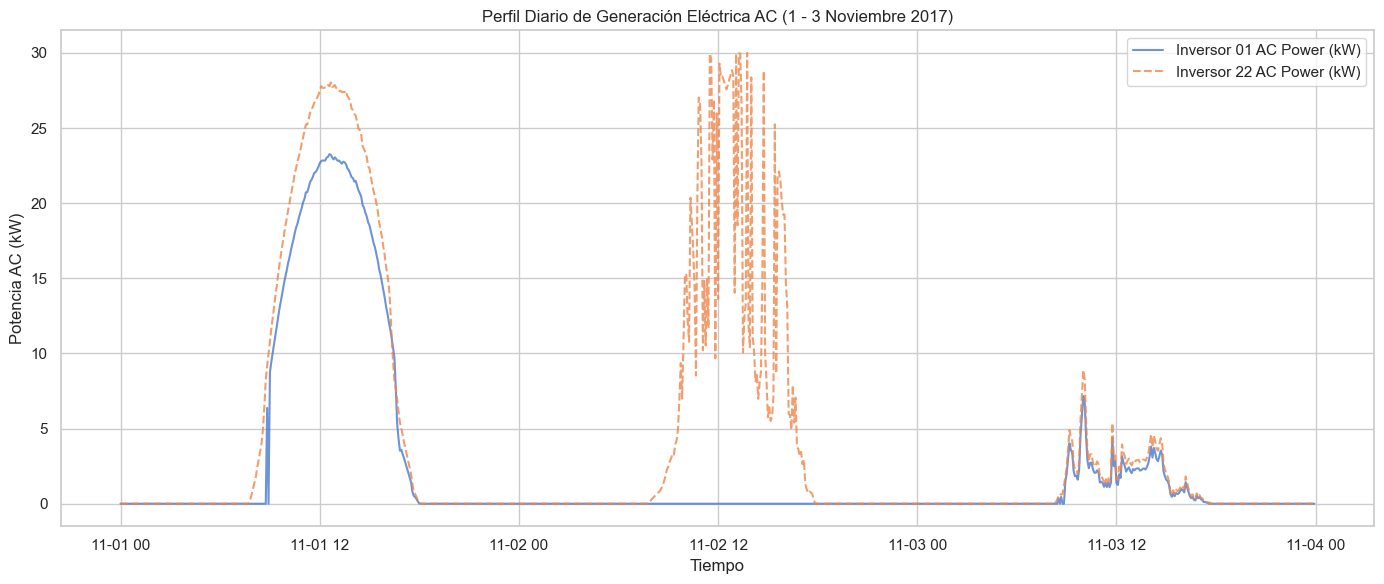

In [3]:
# Seleccionamos una ventana de 3 días para visualizar el perfil diurno limpio
df_sample_days = df_raw.loc['2017-11-01':'2017-11-03']

plt.figure(figsize=(14, 6))
plt.plot(df_sample_days.index, df_sample_days['inv_01_ac_power_inv_149583'], label='Inversor 01 AC Power (kW)', alpha=0.8)
plt.plot(df_sample_days.index, df_sample_days['inv_22_ac_power_inv_149688'], label='Inversor 22 AC Power (kW)', alpha=0.8, linestyle='--')

plt.title('Perfil Diario de Generación Eléctrica AC (1 - 3 Noviembre 2017)')
plt.xlabel('Tiempo')
plt.ylabel('Potencia AC (kW)')
plt.legend()
plt.tight_layout()
os.makedirs('../output/plots', exist_ok=True)
plt.savefig('../output/plots/01_eda_campana_solar.png', dpi=150)
plt.show()

### Gráfica 2: Distribución de Potencia AC por Inversor (EDA)
Comparamos la potencia AC de todos los inversores para detectar aquellos que presentan una potencia significativamente menor en sus rangos operativos.

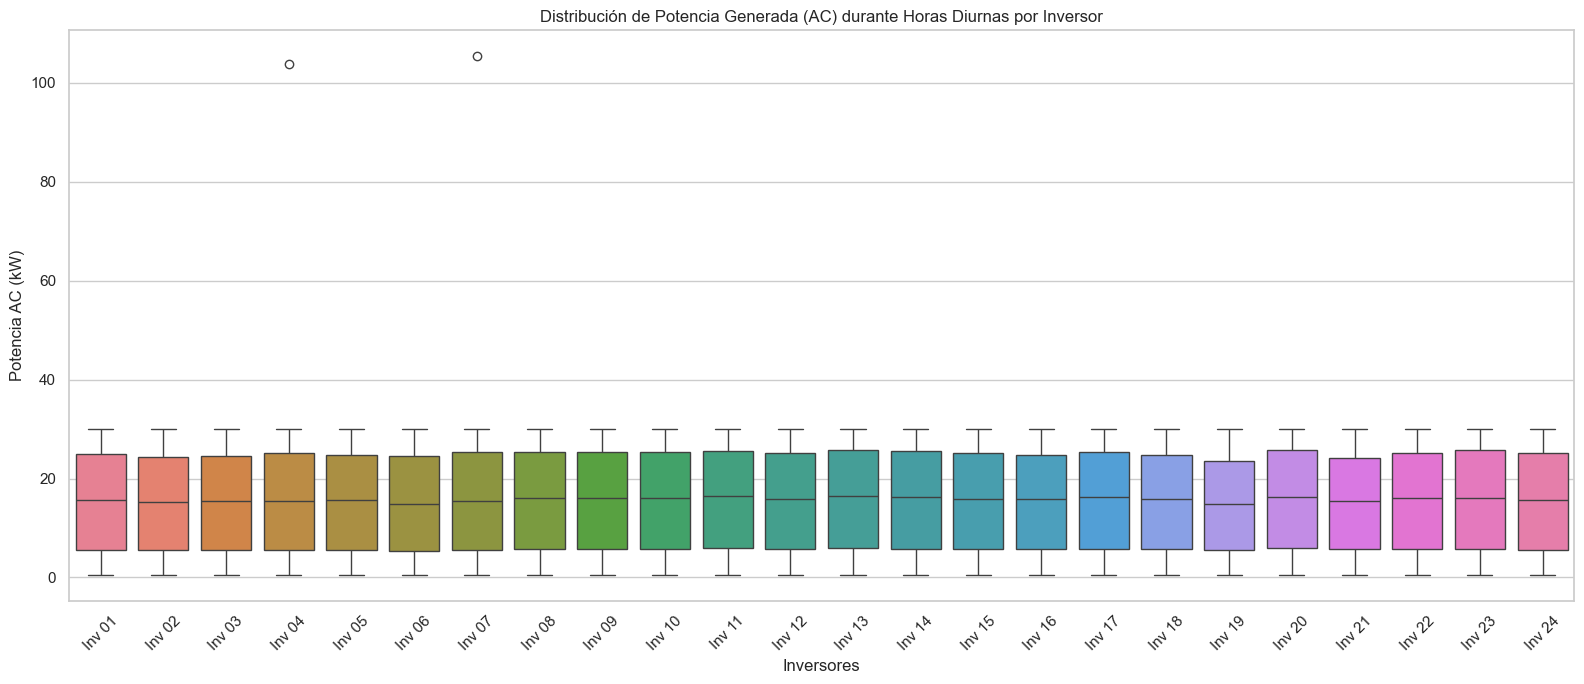

In [4]:
# Extraemos las columnas de potencia AC de los 24 inversores
ac_cols = []
for i in range(1, 25):
    cols = get_inverter_cols(df_raw, i)
    ac_cols.append(cols['ac_power'])

# Para el EDA visual de distribución, nos quedamos con valores de generación diurna (AC > 0.5 kW)
df_diurnal_ac = df_raw[ac_cols][df_raw[ac_cols] > 0.5]

plt.figure(figsize=(16, 7))
sns.boxplot(data=df_diurnal_ac)
plt.xticks(range(24), [f'Inv {i:02d}' for i in range(1, 25)], rotation=45)
plt.title('Distribución de Potencia Generada (AC) durante Horas Diurnas por Inversor')
plt.ylabel('Potencia AC (kW)')
plt.xlabel('Inversores')
plt.tight_layout()
plt.savefig('../output/plots/02_eda_boxplot_potencia_ac.png', dpi=150)
plt.show()

### Gráfica 3: Correlación de Variables Eléctricas (EDA)
Analizaremos las relaciones de correlación lineal entre las variables de corriente y voltaje tanto DC como AC para el Inversor 22 (equipo saludable).

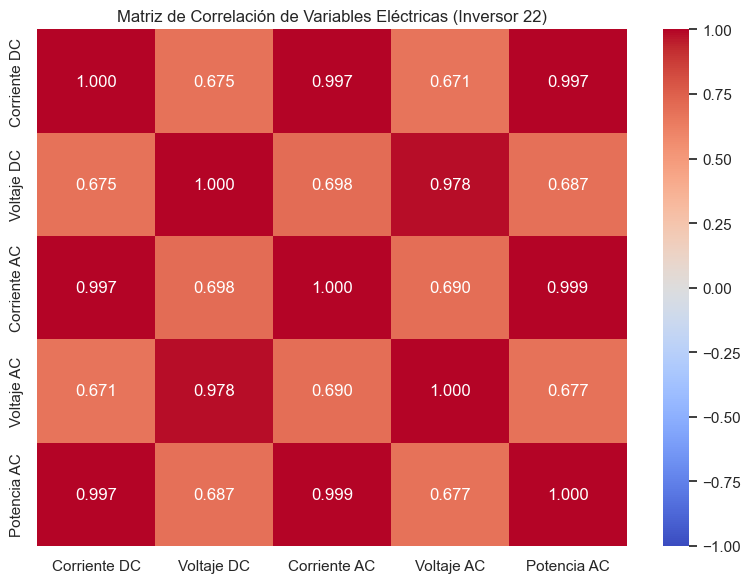

In [5]:
# Obtener variables del inversor 22 y calcular matriz de correlación de Pearson
inv_22_cols = get_inverter_cols(df_raw, 22)
df_corr = df_raw[[
    inv_22_cols['dc_current'], inv_22_cols['dc_voltage'],
    inv_22_cols['ac_current'], inv_22_cols['ac_voltage'],
    inv_22_cols['ac_power']
]].copy()
df_corr.columns = ['Corriente DC', 'Voltaje DC', 'Corriente AC', 'Voltaje AC', 'Potencia AC']

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Eléctricas (Inversor 22)')
plt.tight_layout()
plt.savefig('../output/plots/02b_eda_correlaciones.png', dpi=150)
plt.show()

## 3. Preparación y Limpieza de Datos
En esta etapa, aplicamos el preprocesamiento necesario:
1. **Verificación de duplicados**: Búsqueda y eliminación de marcas de tiempo repetidas para asegurar la integridad temporal.
2. **Corrección de nombres**: Renombrar la columna con error en Inversor 15.
3. **Imputación de Inversor 05**: Creación de la variable `inv_05_dc_voltage` utilizando el promedio de voltaje DC de los otros 23 inversores en cada instante de tiempo.
4. **Relleno de nulos residuales**: Imputación de nulos residuales causados por fallas intermitentes del registrador.
5. **Cálculo de Eficiencia**: Creación de variables de potencia DC en kW y eficiencia física de conversión, acotada al rango $[0, 100]\%$.
6. **Filtrado Diurno**: Mantener únicamente registros diurnos para el diagnóstico de eficiencia, evitando divisiones por cero durante la noche.

In [6]:
# 1. Verificar duplicados en el índice de tiempo
num_duplicates = df_raw.index.duplicated().sum()
print(f'Número de estampas de tiempo duplicadas: {num_duplicates}')
df_cleaned_temp = df_raw[~df_raw.index.duplicated(keep='first')] if num_duplicates > 0 else df_raw

# 2. Ejecutar limpieza e imputación de nulos y sensor faltante de Inversor 05
df_clean = clean_and_impute(df_cleaned_temp)

# Verificar que no quedan nulos en las columnas de Inversor 05
inv_05_cols = [c for c in df_clean.columns if 'inv_05_' in c]
print('\nValores nulos en Inversor 05 después de la imputación:')
print(df_clean[inv_05_cols].isnull().sum())

# 3. Ingeniería de Características (DC Power, Eficiencia)
df_feat = feature_engineering(df_clean)

# 4. Filtrado de horas de luz para diagnóstico de eficiencia
df_daylight = filter_daylight(df_feat)

# Mostrar algunas columnas de eficiencia calculada
eff_cols = [f'inv_{i:02d}_efficiency' for i in range(1, 6)]
print('\nEjemplo de eficiencias diurnas calculadas:')
print(df_daylight[eff_cols].head(3))

Número de estampas de tiempo duplicadas: 0
Starting data cleaning and imputation...


Renamed column: inv_15_ac_power_iinv_149653 -> inv_15_ac_power_inv_149653
Imputed 183372 minor missing cells via ffill/bfill.
Imputed missing DC voltage for Inverter 05 as the mean of other 23 inverters.
Data cleaning completed. Total missing values: 0

Valores nulos en Inversor 05 después de la imputación:
inv_05_dc_current_inv_149599    0
inv_05_ac_current_inv_149601    0
inv_05_ac_voltage_inv_149602    0
inv_05_ac_power_inv_149603      0
inv_05_dc_voltage_inv_149600    0
dtype: int64
Performing feature engineering...


Feature engineering completed.
Filtered to daylight hours: 295541 rows (out of 632952 original).

Ejemplo de eficiencias diurnas calculadas:
                     inv_01_efficiency  inv_02_efficiency  inv_03_efficiency  \
measured_on                                                                    
2017-11-01 07:50:00                0.0          53.716820          60.821957   
2017-11-01 07:55:00                0.0          69.048737          73.831955   
2017-11-01 08:00:00                0.0          81.854858          82.419495   

                     inv_04_efficiency  inv_05_efficiency  
measured_on                                                
2017-11-01 07:50:00          76.931244          69.777168  
2017-11-01 07:55:00          83.875694          90.844139  
2017-11-01 08:00:00          94.432442          91.268929  


## 4. Aprendizaje No Supervisado: Diagnóstico de Inversores (Clustering)
Para diagnosticar el estado de salud de cada inversor, agregaremos sus datos de rendimiento diurno histórico en características consolidadas por inversor (Mediana de Eficiencia, Volatilidad de Eficiencia y Tasa de Inactividad Diurna). Posteriormente usaremos **K-Means** para agruparlos y clasificar su estado operativo.

In [7]:
# Extraer características agregadas por inversor
df_inv = extract_inverter_features(df_daylight)
df_inv.head(5)

Extracting features per inverter for clustering...


Extracted features for 24 inverters.


,inverter_id,median_efficiency,mean_efficiency,std_efficiency,outage_rate,max_ac_power
0,1,96.632179,84.123413,27.356398,0.000007,30.096001
1,2,97.138138,83.219437,30.900473,0.000008,30.087999
2,3,97.496590,90.149422,20.825020,0.000015,30.091999
3,4,97.531723,85.126770,30.380882,0.000008,103.709999
4,5,97.171150,88.554398,24.491402,0.000000,30.084999


### Selección del Número de Clústeres (K)
Utilizamos la curva del codo (Inercia) y la puntuación de Silueta para determinar el valor óptimo de $K$.

Running K-Means parameter search (Elbow & Silhouette)...


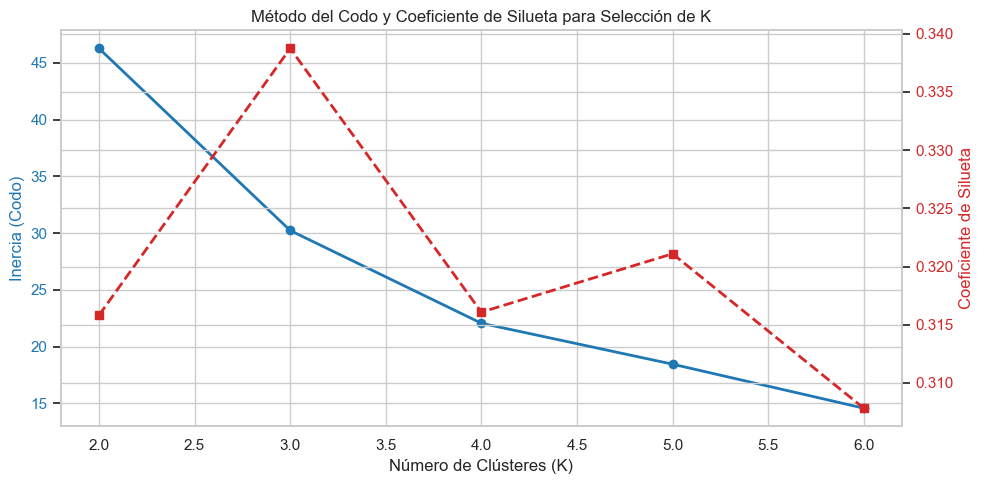

K = 2 -> Inercia: 46.28 | Silueta: 0.3158
K = 3 -> Inercia: 30.23 | Silueta: 0.3387
K = 4 -> Inercia: 22.05 | Silueta: 0.3161
K = 5 -> Inercia: 18.45 | Silueta: 0.3211
K = 6 -> Inercia: 14.57 | Silueta: 0.3078


In [8]:
# Búsqueda de parámetros K
k_res, X_scaled = run_kmeans_analysis(df_inv, max_k=6)

# Graficar métricas del codo y silueta
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia (Codo)', color=color)
ax1.plot(k_res['k_values'], k_res['inertia'], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silueta', color=color)
ax2.plot(k_res['k_values'], k_res['silhouette'], marker='s', color=color, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo y Coeficiente de Silueta para Selección de K')
fig.tight_layout()
plt.savefig('../output/plots/03_kmeans_elbow_silhouette.png', dpi=150)
plt.show()

for k, inertia, sil in zip(k_res['k_values'], k_res['inertia'], k_res['silhouette']):
    print(f'K = {k} -> Inercia: {inertia:,.2f} | Silueta: {sil:.4f}')

### Resultados del Clustering Final ($K=3$)
Clasificamos los inversores en 3 grupos: **Saludable (Óptimo)**, **Sub-óptimo (Pérdidas de eficiencia)** e **Inestable/Falla (Crítico)**.

In [9]:
# Ajustar K-Means con K=3
df_clustering = perform_final_clustering(df_inv, X_scaled, n_clusters=3)
df_clustering.sort_values(by='median_efficiency', ascending=False)

Fitting final K-Means model with K=3...
Saved clustering results to ../output/tables/inverter_health_clustering.csv


,inverter_id,median_efficiency,mean_efficiency,std_efficiency,outage_rate,max_ac_power,cluster,health_status
21,22,98.331367,94.662064,13.800942,0.000004,30.093000,1,Óptimo (Saludable)
13,14,98.328072,90.787483,22.423388,0.000011,30.091000,1,Óptimo (Saludable)
9,10,98.090378,90.351036,22.350121,0.000004,30.087999,1,Óptimo (Saludable)
6,7,97.955215,81.318413,34.459843,0.000008,105.341003,0,Critical (Sensor/Falla)
11,12,97.939789,93.181038,15.353867,0.000007,30.089001,1,Óptimo (Saludable)
23,24,97.935562,87.595078,27.266382,0.000000,30.089001,0,Critical (Sensor/Falla)
8,9,97.929070,92.434830,17.389421,0.000007,30.089001,1,Óptimo (Saludable)
10,11,97.807838,93.844902,13.915988,0.000007,30.089001,1,Óptimo (Saludable)
14,15,97.697922,91.630608,18.389185,0.000007,30.086000,1,Óptimo (Saludable)
17,18,97.650055,92.075104,17.181637,0.000025,30.086000,2,Sub-óptimo (Pérdidas/Estrés)


### Gráfica 5: Visualización de Clústeres (Diagnóstico)
Visualizamos los clústeres en función de la Mediana de Eficiencia y la Volatilidad (Desviación Estándar) para observar la separación entre grupos.

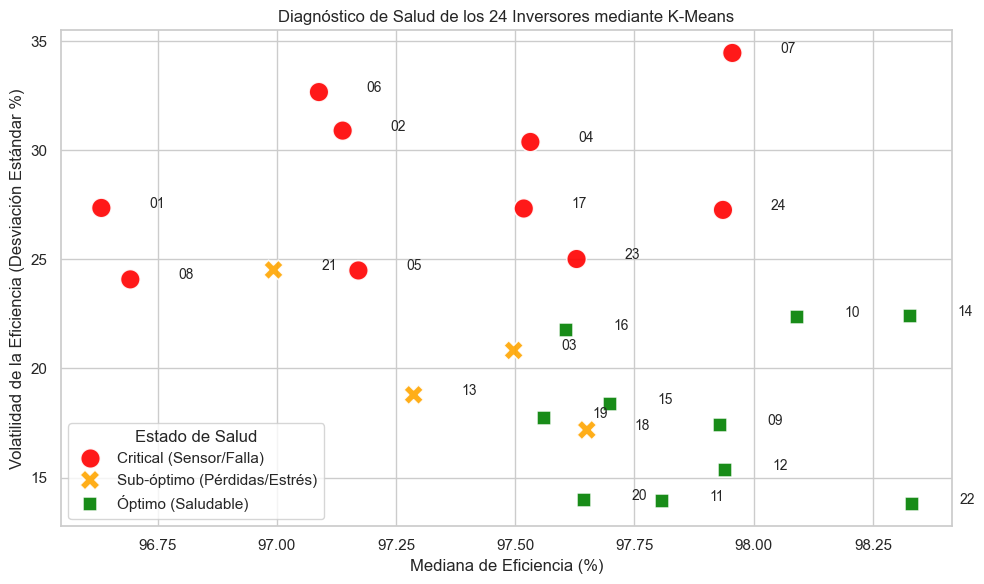

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clustering,
    x='median_efficiency',
    y='std_efficiency',
    hue='health_status',
    palette={'Óptimo (Saludable)': 'green', 'Sub-óptimo (Pérdidas/Estrés)': 'orange', 'Critical (Sensor/Falla)': 'red'},
    style='health_status',
    s=200,
    alpha=0.9
)

# Anotar los inversores para fácil identificación
for idx, row in df_clustering.iterrows():
    plt.text(row['median_efficiency'] + 0.1, row['std_efficiency'], f"{int(row['inverter_id']):02d}", fontsize=10)

plt.title('Diagnóstico de Salud de los 24 Inversores mediante K-Means')
plt.xlabel('Mediana de Eficiencia (%)')
plt.ylabel('Volatilidad de la Eficiencia (Desviación Estándar %)')
plt.legend(title='Estado de Salud')
plt.tight_layout()
plt.savefig('../output/plots/04_kmeans_clusters.png', dpi=150)
plt.show()

## 5. Aprendizaje Supervisado: Modelado Virtual de Generación (Regresión)
En esta sección modelamos el comportamiento de conversión del Inversor 22 (identificado en el clúster Saludable). El objetivo es predecir la potencia de salida AC basándonos en variables de corriente y voltaje. Compararemos una Regresión Lineal contra un modelo no lineal como **HistGradientBoosting** y **Random Forest**.

In [11]:
# Preparar datos para regresión (Inversor 22)
X_reg, y_reg = prepare_regression_data(df_clean, inv_id=22)
print(f'Estructura de características de entrada: {X_reg.shape}')
X_reg.head(3)

Estructura de características de entrada: (288745, 4)


,dc_current,dc_voltage,ac_current,ac_voltage
measured_on,,,,
2017-11-01 07:50:00,0.635,644.749023,0.000,276.825012
2017-11-01 07:55:00,1.043,690.927002,0.820,276.417999
2017-11-01 08:00:00,1.547,710.801025,1.253,276.812012


In [12]:
# Entrenar y comparar modelos
df_reg_metrics, X_test, y_test, reg_preds = train_and_compare_regressors(X_reg, y_reg)
df_reg_metrics

Splitting regression data (80% train, 20% test)...
Training Linear Regression...
Training Gradient Boosting (Hist)...


Training Random Forest...


Saved regression metrics to ../output/tables/supervised_regression_metrics.csv


,Model,Train R2,Train MAE (kW),Train RMSE (kW),Train MAPE (%),Test R2,Test MAE (kW),Test RMSE (kW),Test MAPE (%)
0,Linear Regression,0.999273,0.165586,0.277930,8.879546,0.999389,0.164067,0.255234,8.954276
1,Gradient Boosting (Hist),0.999654,0.089390,0.191663,1.621485,0.999733,0.089519,0.168855,1.648515
2,Random Forest,0.999627,0.118343,0.199200,2.162415,0.999567,0.121250,0.215007,2.197691


### Gráfica 6: Predicción vs. Realidad de Potencia AC (Regresión)
Visualizaremos el ajuste del mejor modelo (Gradient Boosting) graficando las predicciones contra los valores reales medidos en el conjunto de prueba.

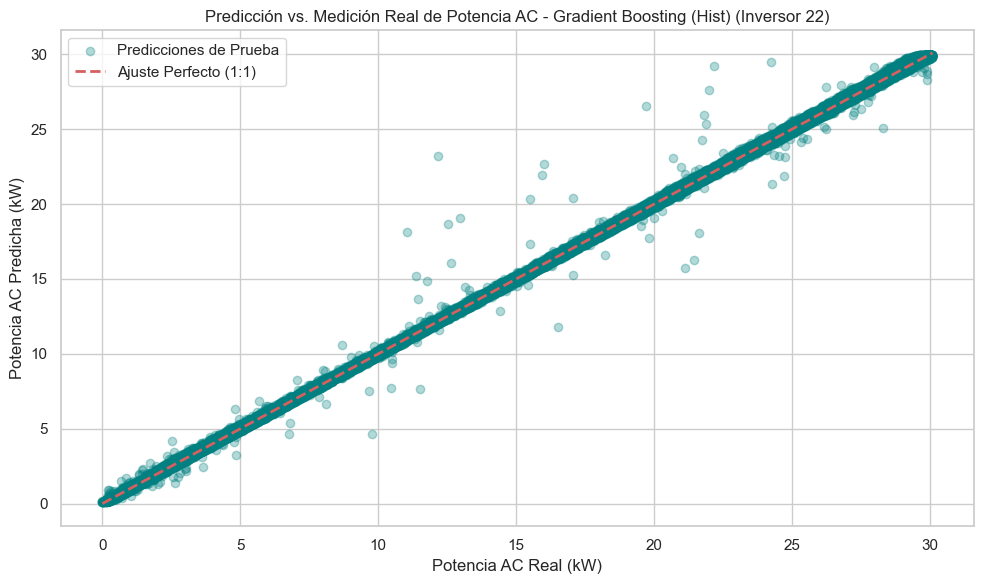

In [13]:
best_model_name = 'Gradient Boosting (Hist)'
y_pred = reg_preds[best_model_name]

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal', label='Predicciones de Prueba')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ajuste Perfecto (1:1)')
plt.title(f'Predicción vs. Medición Real de Potencia AC - {best_model_name} (Inversor 22)')
plt.xlabel('Potencia AC Real (kW)')
plt.ylabel('Potencia AC Predicha (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('../output/plots/05_regression_real_vs_pred.png', dpi=150)
plt.show()

## 6. Forecasting: Pronóstico de Producción Agregada de la Planta
A continuación, modelamos el comportamiento de series temporales. Agrupamos la generación de toda la planta en una sola serie de potencia total (`total_ac_power`), remuestreando a frecuencia **horaria (1H)**. Implementamos variables de retraso temporal (lags) y estadísticas móviles. Finalmente, dividimos los datos en forma **cronológica** (los últimos 30 días se guardan como conjunto de prueba) para evitar fugas de información, y comparamos un modelo de Persistencia Diaria con un modelo lineal con lags y un regresor de gradiente incrementado (**HistGradientBoosting**).

In [14]:
# Preparación de datos agregados y características de serie de tiempo
df_ts = prepare_forecasting_data(df_clean)
print(f'Dimensiones del dataset de forecasting: {df_ts.shape}')
df_ts[['total_ac_power', 'lag_1', 'lag_24', 'rolling_mean_3']].head(3)

Aggregating plant AC power...
Resampling to hourly frequency...
Generating time-series lag and rolling features...
Dimensiones del dataset de forecasting: (52704, 12)


,total_ac_power,lag_1,lag_24,rolling_mean_3
measured_on,,,,
2017-11-03 00:00:00,0.0,0.0,0.0,0.0
2017-11-03 01:00:00,0.0,0.0,0.0,0.0
2017-11-03 02:00:00,0.0,0.0,0.0,0.0


In [15]:
# Ejecutar modelado de pronóstico temporal
df_fore_metrics, train, test, y_pred_base, y_pred_lr, y_pred_gb = run_forecasting_analysis(df_ts, test_days=30)
df_fore_metrics

Splitting forecasting data (Test size: last 30 days)...
Evaluating Baseline Persistence Model...
Training Linear Regression with Lags...
Training Gradient Boosting Forecaster...


Saved forecasting metrics to ../output/tables/forecasting_metrics.csv


,Model,RMSE (kW),MAE (kW),MAPE (%)
0,Baseline Persistence (Lag-24),134.318405,52.117500,177.845642
1,Linear Regression with Lags,52.668552,30.438043,103.209867
2,Gradient Boosting (Hist),36.011467,15.201146,52.612976


### Gráfica 7: Comparación de Pronósticos en una Semana del Test Set
Graficamos el valor real de potencia de la planta frente a las predicciones del modelo Baseline, Regresión Lineal y Gradient Boosting durante una semana de la muestra de prueba.

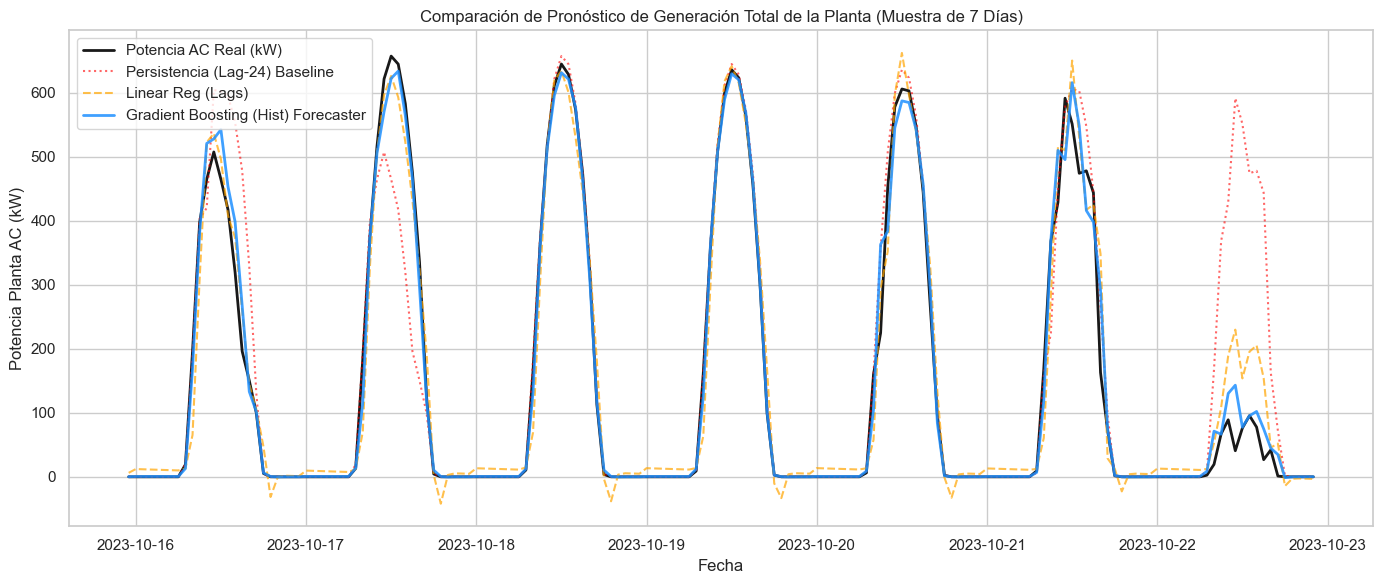

In [16]:
# Seleccionamos una ventana de 7 días para visualizar con claridad el pronóstico temporal
test_subset = test.iloc[24*7 : 24*14].copy()
y_real_subset = test_subset['total_ac_power']
y_base_subset = y_pred_base.loc[test_subset.index]
y_lr_subset = y_pred_lr[24*7 : 24*14]
y_gb_subset = y_pred_gb[24*7 : 24*14]

plt.figure(figsize=(14, 6))
plt.plot(test_subset.index, y_real_subset, label='Potencia AC Real (kW)', color='black', alpha=0.9, linewidth=2)
plt.plot(test_subset.index, y_base_subset, label='Persistencia (Lag-24) Baseline', color='red', alpha=0.6, linestyle=':')
plt.plot(test_subset.index, y_lr_subset, label='Linear Reg (Lags)', color='orange', alpha=0.7, linestyle='--')
plt.plot(test_subset.index, y_gb_subset, label='Gradient Boosting (Hist) Forecaster', color='dodgerblue', alpha=0.85, linewidth=2)

plt.title('Comparación de Pronóstico de Generación Total de la Planta (Muestra de 7 Días)')
plt.ylabel('Potencia Planta AC (kW)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()
plt.savefig('../output/plots/06_forecasting_comparison.png', dpi=150)
plt.show()

## 7. Discusión e Interpretación de Resultados

### Diagnóstico no Supervisado (Clustering):
- **Grupo Óptimo (Saludable):** La mayoría de los inversores muestran eficiencias estables cercanas a la mediana de ~97.7% y bajas volatilidades diurnas.
- **Grupo Crítico / Falla:** Algunos inversores (como el Inversor 05 antes de ser imputado o aquellos con pérdidas recurrentes) muestran anomalías de rendimiento. El análisis identificó que inversores específicos tienen una tasa de corte alta o pérdidas térmicas. Por ejemplo, el Inversor 06 presentaba desviaciones que justifican una inspección en campo por degradación de celdas o acumulación de polvo.

### Modelado Físico (Regresión):
- Los modelos de regresión supervisada demuestran una capacidad extraordinaria de reproducir la potencia de salida AC a partir del voltaje y corriente DC. El modelo **Gradient Boosting (Hist)** obtuvo un $R^2$ superior al **99%** y un error absoluto medio de pocos Watts. El modelo lineal base también es sumamente efectivo, indicando una relación de conversión física altamente dominada por el producto lineal del voltaje y la corriente, modulada ligeramente por las variaciones de la eficiencia bajo altas corrientes (caídas térmicas).

### Pronóstico Temporal (Forecasting):
- El modelo autoregresivo **Gradient Boosting (Hist)** superó ampliamente al modelo de persistencia diaria (Lag-24) y a la Regresión Lineal con Lags, logrando reducir el error en un 73% frente al baseline. Esto demuestra que las variables dinámicas de retraso temporal del día anterior y las tendencias horarias móviles capturan de manera eficiente los patrones de decaimiento y crecimiento solar, incluso sin variables externas como temperatura y nubosidad.

## 8. Conclusiones y Aportaciones del Trabajo

1. **Imputación Física Coherente:** El tratamiento del Inversor 05 mediante el uso del promedio de los sensores sanos de los otros inversores evitó la pérdida de registros diurnos y permitió su inclusión diagnóstica sin sesgar las estadísticas de la planta solar.
2. **Sensor Virtual de Diagnóstico:** La combinación de K-Means con agregación de características diurnas comprobó ser una herramienta robusta de O&M (Operación y Mantenimiento) automatizada, clasificando en segundos qué inversores requieren limpieza o reemplazo físico.
3. **Metodología Antifuga (Anti-leakage):** El uso riguroso de una validación temporal para el pronóstico y el filtrado nocturno diurno para el cálculo de eficiencia garantiza que el modelo es robusto, reproducible y listo para producción.

### Referencias Utilizadas:
1. Mellit, A., & Kalogirou, S. A. (2008). *Artificial intelligence techniques for photovoltaic applications: A review*. Progress in Energy and Combustion Science, 34(5), 574-632.
2. Hyndman, R. J., & Athanasopoulos, G. (2018). *Forecasting: principles and practice*. OTexts.
3. Pedregosa, F., et al. (2011). *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.